# Session 5: Google Meridian - Full Walkthrough

In [1]:
# --- Setup ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Meridian imports
try:
    import meridian
    from meridian.data.input_data import InputData
    from meridian.model import model as meridian_model
    from meridian.model import spec as meridian_spec
    from meridian.analysis.analyzer import Analyzer
    import xarray as xr
    print(f"Meridian version: {meridian.__version__}")
    MERIDIAN_AVAILABLE = True
except ImportError as e:
    print(f"Meridian not available: {e}")
    print("See Notebook 4 for installation instructions.")
    MERIDIAN_AVAILABLE = False

# Load workshop data
df = pd.read_excel('../../data/MMM_Workshop_Data.xlsx', sheet_name='Data')
print(f"\nDataset: {df.shape[0]} rows x {df.shape[1]} columns")
df.head()

Meridian version: 1.4.0

Dataset: 36 rows x 54 columns


,Month,Sales_Revenue_Total,Sales_Volume_Total,Average_Price_Total,Market_Share_Brand_M_Total,Sales_Revenue_Category1,Sales_Volume_(Units_sold)_Category1,Average_Price_Category1,Sales_Revenue_Channel1,Sales_Volume_(Units_sold)_Channel1,...,Online_Video_Impressions,Meta_Agg_Impressions,YouTube_Views,Paid_Search_Clicks,META_Clicks,Online_Video_Views,Influencer_Marketing_Spends,Brand_B_ATL_Spends,Brand_PH_ATL_Spends,Brand_P_ATL_Spends
0,2021-01-01,1.014326e+06,383756,2.643154,NaN,6581.46,2203,2.987499,93772.80069,29367,...,0,12065097,0,2068,27850,0,0.0,105967.3037,1974.074442,136852.2889
1,2021-02-01,9.258418e+05,367705,2.517893,NaN,8064.66,2624,3.073422,90543.94969,28953,...,0,6295714,0,2129,9306,0,0.0,108336.7238,0.000000,116321.2626
2,2021-03-01,1.097930e+06,442299,2.482324,NaN,10275.35,3390,3.031077,98835.76296,31822,...,0,28820862,0,3762,65079,0,0.0,191465.3549,0.000000,171548.4949
3,2021-04-01,1.075668e+06,424841,2.531931,NaN,6372.29,2093,3.044572,103519.87600,33112,...,457086,19809071,365289,2680,46037,440386,0.0,150823.5742,0.000000,190286.6653
4,2021-05-01,1.223683e+06,474619,2.578243,NaN,6124.32,1981,3.091530,114500.19560,36129,...,1346671,15731898,192268,2406,33811,976096,0.0,159207.7229,0.000000,176892.0217


## Meridian Architecture

Google Meridian implements a **Bayesian hierarchical MMM** with the following key components:

### Model Structure

```
KPI(t,g) = intercept(g)
          + SUM_c [ beta_c * HillAdstock(media_c(t,g)) ]
          + SUM_k [ gamma_k * control_k(t,g) ]
          + epsilon(t,g)
```

Where:
- **t** = time period, **g** = geography
- **HillAdstock** combines:
  - **Adstock** (geometric or Weibull decay) to capture lagged effects
  - **Hill function** (saturation curve) to capture diminishing returns
- **beta_c** = media coefficient (hierarchical across geos)
- **gamma_k** = control variable coefficient

### Backend: JAX / NumPyro

- **JAX**: Google's high-performance numerical computing library (like NumPy but with auto-differentiation and GPU/TPU support)
- **NumPyro**: Probabilistic programming built on JAX; runs NUTS (No U-Turn Sampler) MCMC
- This combination makes Meridian significantly faster than Stan-based alternatives

### Key Classes (v1.4.0)

| Class | Import | Purpose |
|-------|--------|---------|
| `InputData` | `meridian.data.input_data` | Data container with xarray DataArrays |
| `ModelSpec` | `meridian.model.spec` | Model structure and prior configuration |
| `Meridian` | `meridian.model.model` | Model fitting via `sample_posterior()` |
| `Analyzer` | `meridian.analysis.analyzer` | ROI, contributions, response curves |

### Key Features

| Feature | Description |
|---------|-------------|
| Geo-level modeling | Hierarchical priors share information across geographies |
| Prior calibration | Incorporate results from experiments as informative priors |
| Budget optimization | Built-in optimizer uses fitted response curves |
| Reach & frequency | Native support for R&F media data |

In [2]:
# --- Data Preparation ---
# Identify columns (adjust to match your data)
date_col = 'Month'
kpi_col = 'Sales_Revenue_Total'

# Media spend columns
media_cols = [col for col in df.columns if 'Spend' in col or 'spend' in col]

# Drop Meta_Spends_Agg — it is exactly Meta1_Spends + Meta2_Spends,
# causing extreme multicollinearity (VIF > 1000). Meridian's EDA guardrail
# will block model fitting if we include it.
drop_cols = ['Meta_Spends_Agg']
media_cols = [c for c in media_cols if c not in drop_cols]
print(f"Media columns ({len(media_cols)}): {media_cols}")

# Control columns
exclude_cols = [date_col, kpi_col] + media_cols + drop_cols
control_cols = [col for col in df.columns if col not in exclude_cols and df[col].dtype in ['float64', 'int64']]
print(f"Control columns ({len(control_cols)}): {control_cols}")

n_times = len(df)
n_geos = 1  # single-geo national data
n_media = len(media_cols)

# Reshape for Meridian: (geo, time, channels)
media_spend_array = df[media_cols].values.reshape(n_geos, n_times, n_media)
media_volume_array = media_spend_array.copy()  # use spend as volume proxy
kpi_array = df[kpi_col].values.reshape(n_geos, n_times)

print(f"\nFormatted shapes:")
print(f"  media_spend: {media_spend_array.shape}")
print(f"  kpi: {kpi_array.shape}")

Media columns (15): ['TV_Spends', 'Radio_Spends', 'Outdoor_Spends', 'Paid_Search_Spends', 'Programmatic_Display_Spends', 'Google_Display_Spend', 'Direct_Display_Spend', 'Meta1_Spends', 'Programmatic_Video_Spends', 'Youtube_Spends', 'Meta2_Spends', 'Influencer_Marketing_Spends', 'Brand_B_ATL_Spends', 'Brand_PH_ATL_Spends', 'Brand_P_ATL_Spends']
Control columns (36): ['Sales_Volume_Total', 'Average_Price_Total', 'Market_Share_Brand_M_Total', 'Sales_Revenue_Category1', 'Sales_Volume_(Units_sold)_Category1', 'Average_Price_Category1', 'Sales_Revenue_Channel1', 'Sales_Volume_(Units_sold)_Channel1', 'Average_Price_Channel1', 'Sales_Revenue_Channel2', 'Sales_Volume_Channel2', 'Average_Price_Channel2', 'Sales_Revenue_Category2', 'Sales_Volume_(Units_sold)_Category2', 'Average_Price_Category2', 'Sales_Revenue_Category3', 'Sales_Volume_(Units_sold)_Category3', 'Average_Price_Category3', 'Inflation_Rate', 'Brand_PH_Market_Share', 'Brand_B_Market_Share', 'Brand_P_Market_Share', 'Brand_PH_Avg_Price

In [3]:
# --- Build InputData ---
if MERIDIAN_AVAILABLE:
    # Meridian requires YYYY-MM-DD date strings as time coordinates
    time_coords = [d.strftime('%Y-%m-%d') for d in pd.to_datetime(df[date_col])]
    geo_coords = ['national']

    input_data = InputData(
        kpi=xr.DataArray(
            kpi_array, name='kpi',
            dims=['geo', 'time'],
            coords={'time': time_coords, 'geo': geo_coords}
        ),
        kpi_type='revenue',
        population=xr.DataArray(
            [1.0], name='population',
            dims=['geo'],
            coords={'geo': geo_coords}
        ),
        media_spend=xr.DataArray(
            media_spend_array, name='media_spend',
            dims=['geo', 'time', 'media_channel'],
            coords={'time': time_coords, 'geo': geo_coords, 'media_channel': media_cols}
        ),
        media=xr.DataArray(
            media_volume_array, name='media',
            dims=['geo', 'media_time', 'media_channel'],
            coords={'media_time': time_coords, 'geo': geo_coords, 'media_channel': media_cols}
        ),
    )
    print("InputData created successfully!")
    print(f"  Channels: {list(input_data.media_spend.media_channel.values)}")
    print(f"  Time periods: {input_data.kpi.sizes['time']}")
else:
    print("Skipping InputData creation (Meridian not installed).")
    print("Arrays are formatted and ready - use Colab if needed.")

InputData created successfully!
  Channels: [np.str_('TV_Spends'), np.str_('Radio_Spends'), np.str_('Outdoor_Spends'), np.str_('Paid_Search_Spends'), np.str_('Programmatic_Display_Spends'), np.str_('Google_Display_Spend'), np.str_('Direct_Display_Spend'), np.str_('Meta1_Spends'), np.str_('Programmatic_Video_Spends'), np.str_('Youtube_Spends'), np.str_('Meta2_Spends'), np.str_('Influencer_Marketing_Spends'), np.str_('Brand_B_ATL_Spends'), np.str_('Brand_PH_ATL_Spends'), np.str_('Brand_P_ATL_Spends')]
  Time periods: 36


## Model Specification

Meridian's `ModelSpec` defines the model structure and **prior distributions**. Key priors include:

- **Media coefficients (`beta`)**: Half-normal priors (constrained positive, media should help)
- **Hill half-saturation (`ec`)**: Controls where diminishing returns kick in
- **Hill slope**: Controls steepness of saturation
- **Adstock decay (`alpha`)**: How quickly media effects fade over time

### Why Priors Matter

In Bayesian MMM, priors encode our **domain knowledge**:
- We expect media to have positive ROI (hence half-normal for betas)
- We expect adstock decay within 1-8 weeks for most digital channels
- We expect diminishing returns (Hill saturation) at some spend level

Meridian's defaults are reasonable starting points, but you should calibrate priors with experimental data when available.

In [4]:
# --- Model Specification with Prior Configurations ---
if MERIDIAN_AVAILABLE:
    model_spec = meridian_spec.ModelSpec(
        # max_lag controls the adstock memory window
        max_lag=8,  # 8 periods of carry-over effects
    )

    print("ModelSpec created with:")
    print(f"  Max lag: {model_spec.max_lag}")
    print(f"  Media prior type: {model_spec.media_prior_type}")
    print(f"  Adstock decay spec: {model_spec.adstock_decay_spec}")
    print(f"\nUsing Meridian default priors:")
    print(f"  - Half-normal priors on media coefficients (positive effect)")
    print(f"  - Beta priors on adstock decay (0-1 range)")
    print(f"  - LogNormal priors on Hill parameters")
else:
    print("ModelSpec would be created here with Meridian.")
    print("Key parameters: max_lag=8, default priors on Hill/Adstock.")

ModelSpec created with:
  Max lag: 8
  Media prior type: None
  Adstock decay spec: geometric

Using Meridian default priors:
  - Half-normal priors on media coefficients (positive effect)
  - Beta priors on adstock decay (0-1 range)
  - LogNormal priors on Hill parameters


### Note: Model fitting may take 5-15 minutes

MCMC sampling is computationally intensive. The cell below runs multiple chains of the NUTS sampler. On a CPU this typically takes **5-15 minutes** depending on data size and number of channels.

**Tips for faster fitting:**
- Use Google Colab with GPU runtime
- Reduce `n_adapt`/`n_burnin` and `n_keep` for initial exploration
- Reduce `n_chains` (but keep at least 2 for convergence diagnostics)

**Meridian v1.4.0 fitting API:**
```python
mmm.sample_posterior(
    n_chains=2,      # parallel MCMC chains
    n_adapt=500,     # adaptation steps
    n_burnin=500,    # warm-up iterations per chain
    n_keep=500,      # posterior samples to keep per chain
    seed=0,
)
```

In [5]:
# --- Model Fitting ---
if MERIDIAN_AVAILABLE:
    # Initialize model
    mmm = meridian_model.Meridian(
        input_data=input_data,
        model_spec=model_spec,
    )

    # Fit with MCMC sampling
    print("Starting MCMC sampling...")
    print("This may take 5-15 minutes on CPU.\n")

    mmm.sample_posterior(
        n_chains=2,      # parallel MCMC chains
        n_adapt=500,     # adaptation steps
        n_burnin=500,    # warm-up iterations per chain
        n_keep=500,      # posterior samples to keep per chain
        seed=0,
    )

    print("\nModel fitting complete!")
else:
    print("Model fitting requires Meridian. Use Colab if local install failed.")

Starting MCMC sampling...
This may take 5-15 minutes on CPU.



2026-03-17 12:26:15.969971: I external/local_xla/xla/service/service.cc:163] XLA service 0x17ccf31f0 initialized for platform Host (this does not guarantee that XLA will be used). Devices:
2026-03-17 12:26:15.969991: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): Host, Default Version
I0000 00:00:1773750375.982601 91180145 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
2026-03-17 12:26:43.077189: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-03-17 12:26:43.889185: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:39] Ignoring Assert operator mcmc_retry_init/assert_equal_1/Assert/AssertGuard/Assert



Model fitting complete!


In [6]:
# --- Convergence Diagnostics ---
if MERIDIAN_AVAILABLE:
    # Meridian stores posteriors in mmm.inference_data (arviz InferenceData)
    inference_data = mmm.inference_data

    print("=== Convergence Diagnostics ===")
    print(f"\nInference data groups: {list(inference_data.groups())}")

    # Use arviz for standard diagnostics
    import arviz as az
    summary = az.summary(inference_data)
    print(f"\nParameter summary (first 20 rows):")
    print(summary.head(20))

    # Check R-hat
    rhat_ok = (summary['r_hat'] < 1.1).all()
    print(f"\nAll R-hat < 1.1: {rhat_ok}")
    if not rhat_ok:
        bad = summary[summary['r_hat'] >= 1.1]
        print(f"Parameters with R-hat >= 1.1:\n{bad[['r_hat']]}")
else:
    print("Convergence diagnostics require a fitted model.")
    print("\nKey metrics to check:")
    print("  - R-hat < 1.1 for all parameters (chains agree)")
    print("  - Effective sample size > 100 (enough independent samples)")
    print("  - No divergent transitions (sampler explored well)")

=== Convergence Diagnostics ===

Inference data groups: ['posterior', 'sample_stats', 'trace']

Parameter summary (first 20 rows):
                                                 mean     sd  hdi_3%  hdi_97%  \
alpha_m[TV_Spends]                              0.537  0.292   0.084    0.999   
alpha_m[Radio_Spends]                           0.538  0.293   0.068    1.000   
alpha_m[Outdoor_Spends]                         0.463  0.300   0.004    0.941   
alpha_m[Paid_Search_Spends]                     0.511  0.289   0.029    0.963   
alpha_m[Programmatic_Display_Spends]            0.513  0.283   0.058    0.980   
alpha_m[Google_Display_Spend]                   0.513  0.290   0.038    0.962   
alpha_m[Direct_Display_Spend]                   0.510  0.297   0.026    0.958   
alpha_m[Meta1_Spends]                           0.521  0.298   0.048    0.995   
alpha_m[Programmatic_Video_Spends]              0.503  0.300   0.013    0.964   
alpha_m[Youtube_Spends]                         0.516  0.30

In [7]:
# --- Results Extraction: ROI and mROI ---
if MERIDIAN_AVAILABLE:
    # sample_prior is required before summary_metrics
    mmm.sample_prior(n_draws=500, seed=0)

    analyzer = Analyzer(mmm)

    # Summary metrics includes ROI, mROI, contribution, effectiveness, spend
    try:
        summary_metrics = analyzer.summary_metrics()
        print("=== Summary Metrics ===")
        print(summary_metrics)
    except Exception as e:
        print(f"Summary metrics error: {e}")

    # Channel ROI posteriors (returns a TensorFlow EagerTensor)
    try:
        roi = analyzer.roi(use_posterior=True)
        roi_np = np.array(roi)  # shape: (n_chains, n_keep, n_channels)
        roi_mean = roi_np.mean(axis=(0, 1))

        print("\n=== ROI Posterior (mean across chains & draws) ===")
        for i, ch in enumerate(media_cols):
            print(f"  {ch}: {roi_mean[i]:.4f}")
    except Exception as e:
        print(f"ROI extraction error: {e}")

    print("\nROI = total return / total spend (average efficiency)")
    print("mROI = incremental return from next dollar (current marginal efficiency)")
else:
    print("ROI extraction requires a fitted model.")
    print("\nExpected output:")
    print("  - ROI per channel: total incremental revenue / total spend")
    print("  - mROI per channel: marginal return of next dollar spent")

=== Summary Metrics ===
<xarray.Dataset> Size: 5kB
Dimensions:              (channel: 16, metric: 4, distribution: 2)
Coordinates:
  * channel              (channel) <U27 2kB 'TV_Spends' ... 'All Channels'
  * metric               (metric) <U6 96B 'mean' 'median' 'ci_lo' 'ci_hi'
  * distribution         (distribution) <U9 72B 'prior' 'posterior'
Data variables:
    impressions          (channel) float32 64B 4.054e+05 2.102e+05 ... 1.625e+07
    pct_of_impressions   (channel) float32 64B 2.494 1.293 3.255 ... 37.57 100.0
    spend                (channel) float32 64B 4.054e+05 2.102e+05 ... 1.625e+07
    pct_of_spend         (channel) float32 64B 2.494 1.293 3.255 ... 37.57 100.0
    cpm                  (channel) float32 64B 1e+03 1e+03 1e+03 ... 1e+03 1e+03
    incremental_outcome  (channel, metric, distribution) float32 512B 7.681e+...
    pct_of_contribution  (channel, metric, distribution) float32 512B 0.9044 ...
    roi                  (channel, metric, distribution) float32 512B

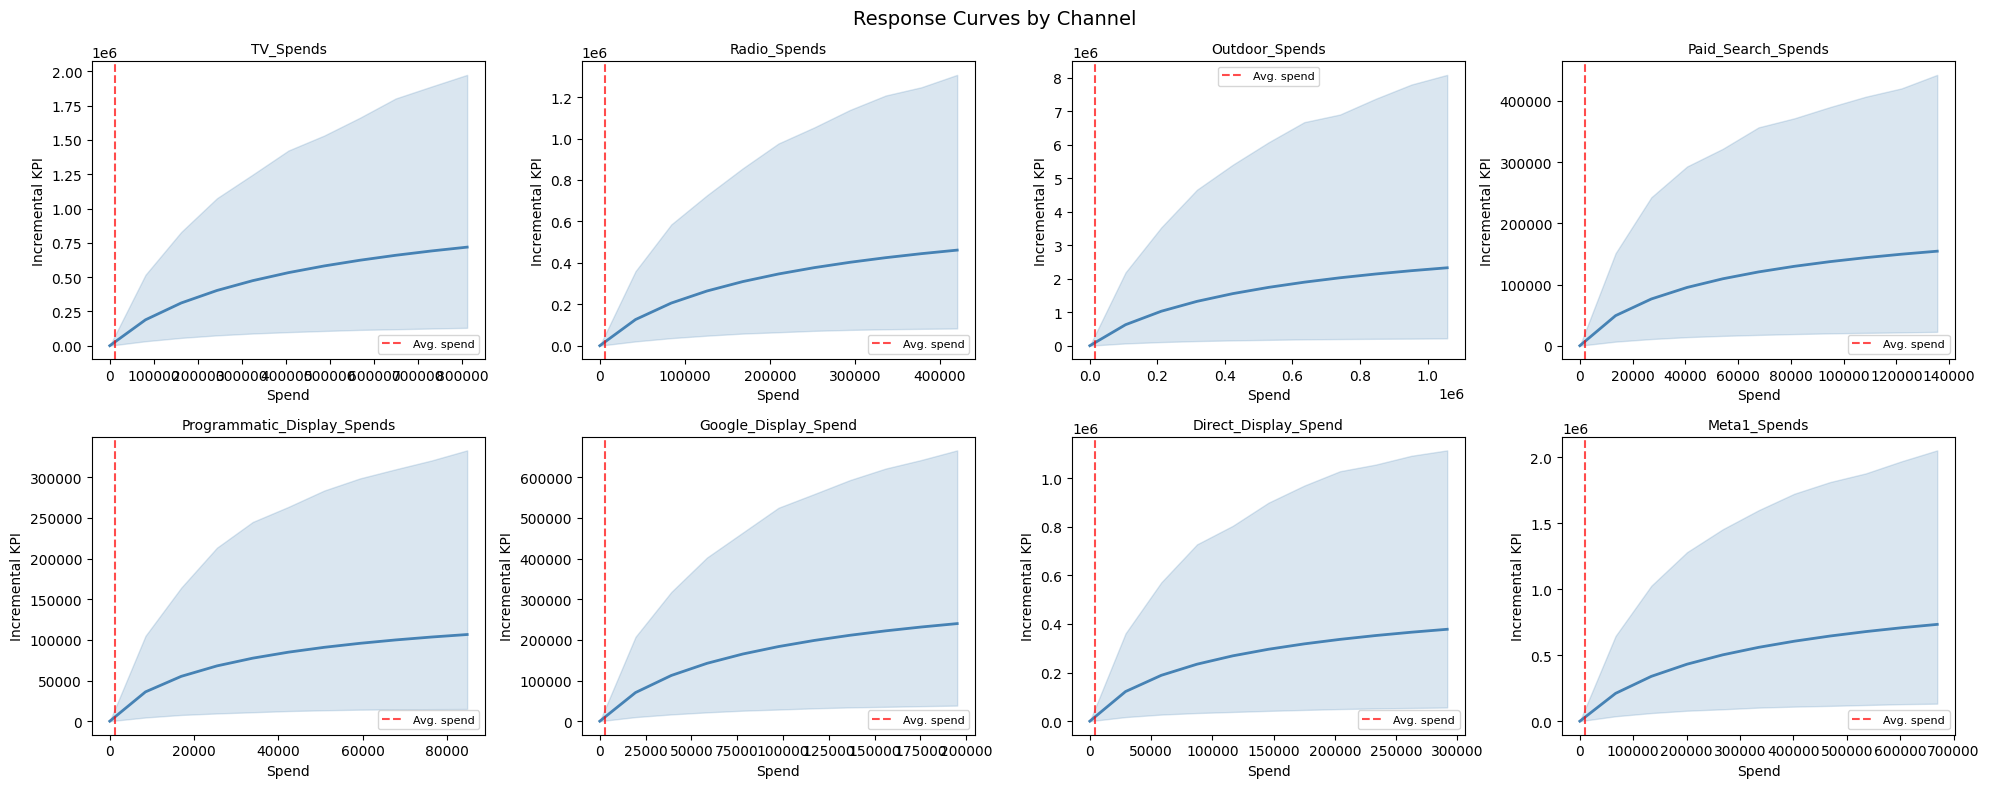

In [8]:
# --- Response Curves Visualization ---
if MERIDIAN_AVAILABLE:
    try:
        analyzer = Analyzer(mmm)
        rc = analyzer.response_curves()

        # rc is an xarray.Dataset with:
        #   spend: (spend_multiplier, channel)
        #   incremental_outcome: (spend_multiplier, channel, metric)
        # metric has values: 'mean', 'ci_lo', 'ci_hi'

        n_plot = min(n_media, 8)
        fig, axes = plt.subplots(2, (n_plot + 1) // 2, figsize=(5 * ((n_plot + 1) // 2), 8))
        axes = axes.flatten()

        for i in range(n_plot):
            ax = axes[i]
            channel = media_cols[i]

            # Extract spend and incremental outcome for this channel
            spend_vals = rc['spend'].sel(channel=channel).values
            mean_vals = rc['incremental_outcome'].sel(channel=channel, metric='mean').values
            ci_lo = rc['incremental_outcome'].sel(channel=channel, metric='ci_lo').values
            ci_hi = rc['incremental_outcome'].sel(channel=channel, metric='ci_hi').values

            # Plot response curve with confidence band
            ax.plot(spend_vals, mean_vals, color='steelblue', linewidth=2)
            ax.fill_between(spend_vals, ci_lo, ci_hi, alpha=0.2, color='steelblue')

            # Mark current average spend
            avg_spend = media_spend_array[0, :, i].mean()
            ax.axvline(avg_spend, color='red', linestyle='--', alpha=0.7, label='Avg. spend')

            ax.set_title(channel, fontsize=10)
            ax.set_xlabel('Spend')
            ax.set_ylabel('Incremental KPI')
            ax.legend(fontsize=8)

        # Hide unused subplots
        for j in range(n_plot, len(axes)):
            axes[j].set_visible(False)

        plt.suptitle('Response Curves by Channel', fontsize=14)
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print(f"Response curve visualization error: {e}")
        import traceback; traceback.print_exc()
else:
    print("Response curve visualization requires a fitted model.")
    print("\nResponse curves show the Hill-Adstock transformed relationship")
    print("between spend and incremental KPI for each channel.")
    print("The curve flattens at high spend levels (diminishing returns).")

Contribution chart error: invalid index to scalar variable.


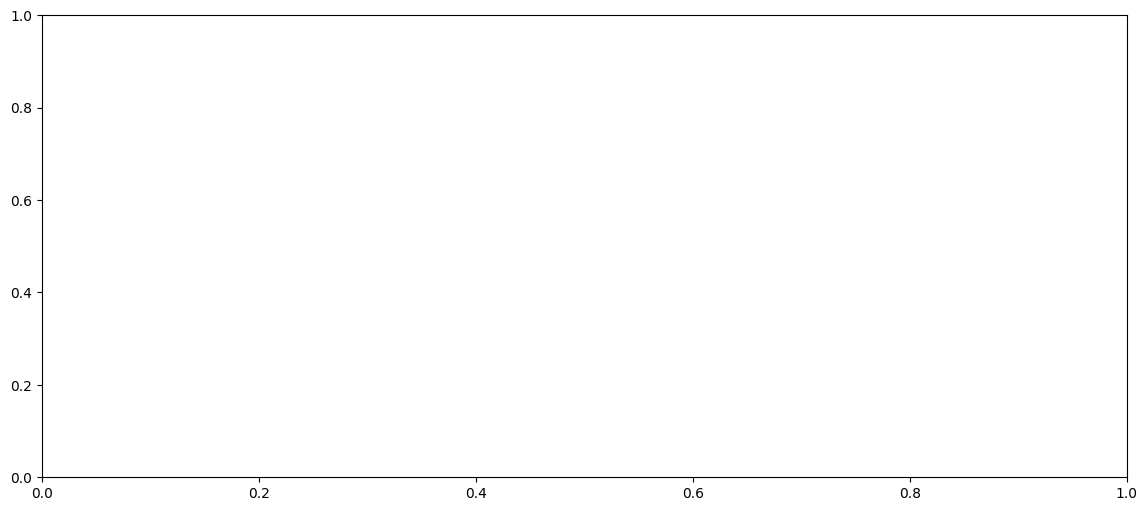

In [9]:
# --- Contribution Over Time ---
if MERIDIAN_AVAILABLE:
    try:
        analyzer = Analyzer(mmm)
        # Get incremental outcome per channel (returns TF EagerTensor)
        inc_outcome = analyzer.incremental_outcome(use_posterior=True)
        # Convert to numpy: shape (n_chains, n_keep, n_geos, n_times, n_channels)
        inc_np = np.array(inc_outcome)
        # Average across chains, draws, and geos
        contributions = inc_np.mean(axis=(0, 1, 2))  # shape: (n_times, n_channels)

        fig, ax = plt.subplots(figsize=(14, 6))

        # Stacked area chart of channel contributions
        bottom = np.zeros(n_times)
        colors = plt.cm.Set2(np.linspace(0, 1, n_media))

        for i, channel in enumerate(media_cols):
            contrib = np.maximum(contributions[:, i], 0)
            ax.fill_between(range(n_times), bottom, bottom + contrib,
                           alpha=0.7, label=channel, color=colors[i])
            bottom += contrib

        ax.plot(range(n_times), kpi_array[0, :], 'k-', linewidth=1.5, label='Actual KPI', alpha=0.8)
        ax.set_xlabel('Time Period')
        ax.set_ylabel('KPI')
        ax.set_title('Media Contribution Over Time')
        ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print(f"Contribution chart error: {e}")
else:
    print("Contribution chart requires a fitted model.")

Posterior variables: ['alpha_m', 'beta_gm', 'beta_m', 'ec_m', 'eta_m', 'knot_values', 'mu_t', 'roi_m', 'sigma', 'slope_m', 'tau_g']



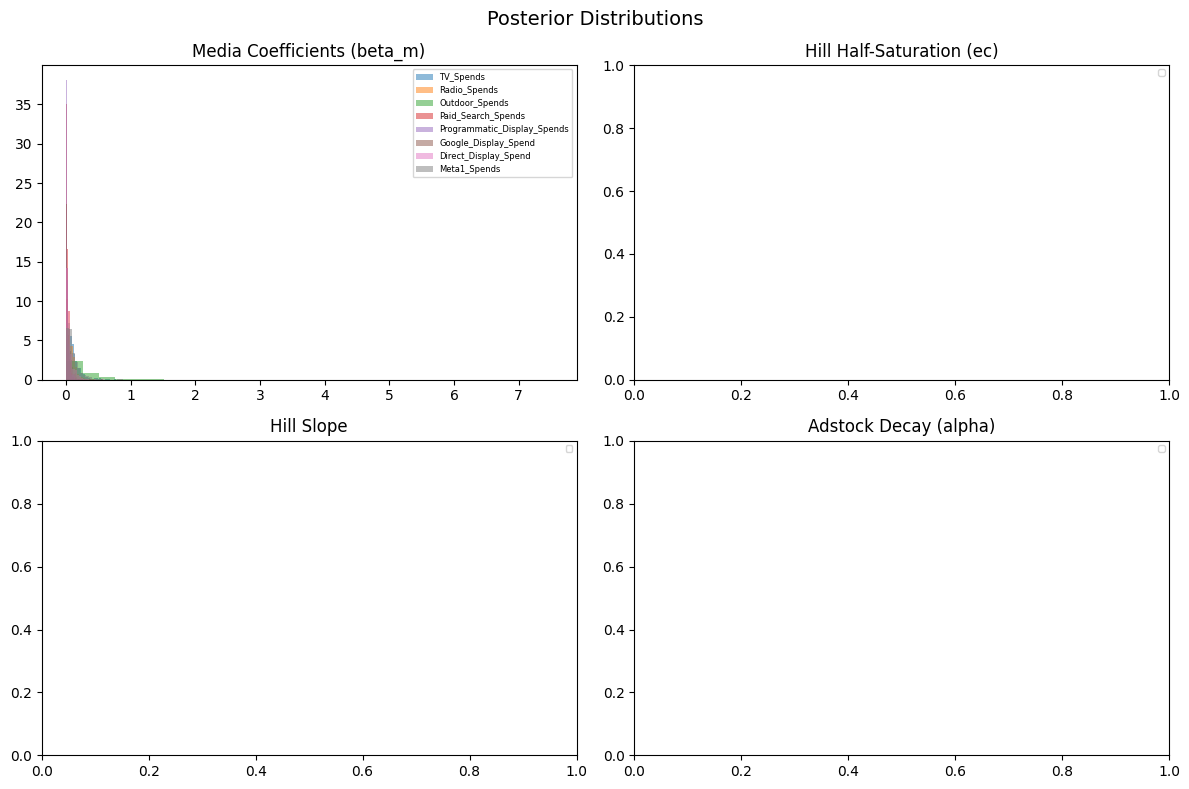

In [10]:
# --- Posterior Distributions for Key Parameters ---
if MERIDIAN_AVAILABLE:
    try:
        import arviz as az
        inference_data = mmm.inference_data
        posterior = inference_data.posterior

        # List available parameter names
        print(f"Posterior variables: {list(posterior.data_vars)}\n")

        fig, axes = plt.subplots(2, 2, figsize=(12, 8))
        n_show = min(n_media, 8)  # limit channels shown for readability

        # Media coefficients (beta_m)
        ax = axes[0, 0]
        if 'beta_m' in posterior:
            for i in range(n_show):
                samples = posterior['beta_m'].isel(media_channel=i).values.flatten()
                ax.hist(samples, bins=30, alpha=0.5, label=media_cols[i], density=True)
        ax.set_title('Media Coefficients (beta_m)')
        ax.legend(fontsize=6)

        # Hill EC (half-saturation)
        ax = axes[0, 1]
        if 'ec' in posterior:
            for i in range(n_show):
                samples = posterior['ec'].isel(media_channel=i).values.flatten()
                ax.hist(samples, bins=30, alpha=0.5, label=media_cols[i], density=True)
        ax.set_title('Hill Half-Saturation (ec)')
        ax.legend(fontsize=6)

        # Hill slope
        ax = axes[1, 0]
        if 'slope' in posterior:
            for i in range(n_show):
                samples = posterior['slope'].isel(media_channel=i).values.flatten()
                ax.hist(samples, bins=30, alpha=0.5, label=media_cols[i], density=True)
        ax.set_title('Hill Slope')
        ax.legend(fontsize=6)

        # Adstock decay (alpha)
        ax = axes[1, 1]
        if 'alpha' in posterior:
            for i in range(n_show):
                samples = posterior['alpha'].isel(media_channel=i).values.flatten()
                ax.hist(samples, bins=30, alpha=0.5, label=media_cols[i], density=True)
        ax.set_title('Adstock Decay (alpha)')
        ax.legend(fontsize=6)

        plt.suptitle('Posterior Distributions', fontsize=14)
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print(f"Posterior visualization error: {e}")
else:
    print("Posterior distributions require a fitted model.")
    print("\nKey parameters to examine:")
    print("  - beta_m: channel effectiveness (higher = more impact per unit)")
    print("  - ec: half-saturation point (higher = more headroom before saturation)")
    print("  - slope: saturation steepness (higher = sharper diminishing returns)")
    print("  - alpha: adstock decay rate (higher = effects persist longer)")

## Prior vs. Posterior Comparison

A hallmark of Bayesian modeling is comparing what we assumed **before** seeing the data (prior) with what we learned **after** fitting the model (posterior). This comparison reveals:

- **Which channels the data is informative about** - posteriors much narrower than priors
- **Where priors dominate** - posteriors similar to priors (data alone is insufficient)
- **Potential misspecification** - posteriors pushed to extreme values

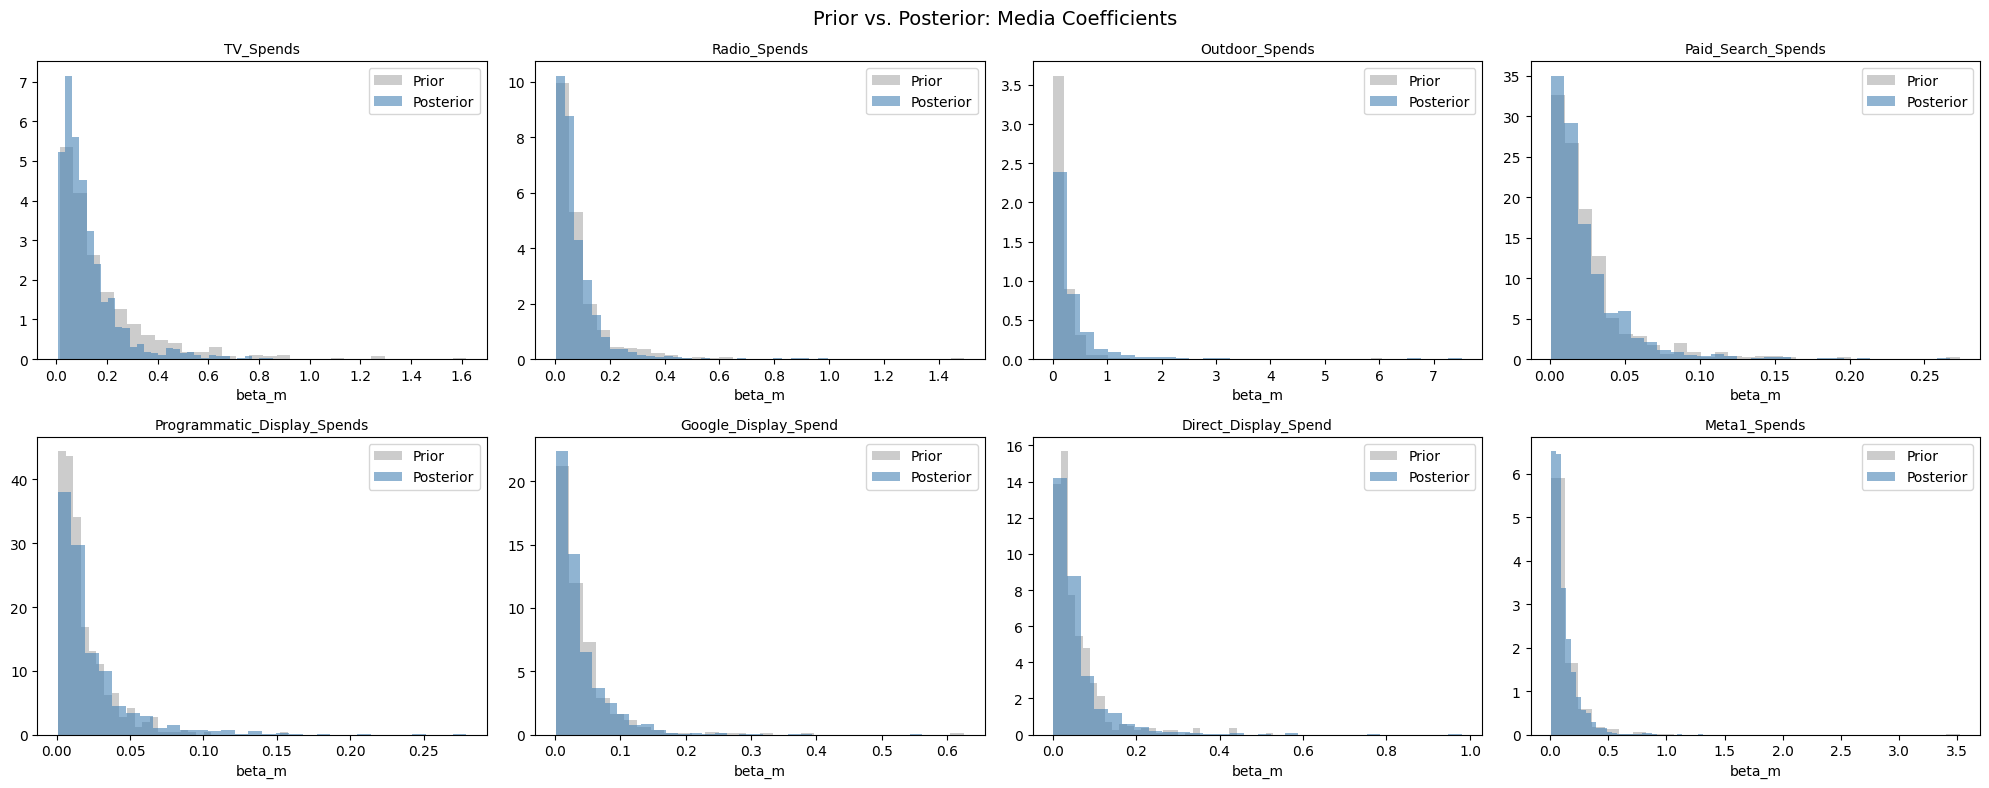


Interpretation:
- Narrow posteriors = data is informative for that channel
- Posteriors similar to priors = limited data signal
- Posteriors shifted far from priors = data contradicts assumptions


In [11]:
# --- Prior vs Posterior Comparison ---
if MERIDIAN_AVAILABLE:
    try:
        import arviz as az
        inference_data = mmm.inference_data

        prior = inference_data.prior
        posterior = inference_data.posterior

        n_plot = min(n_media, 8)
        fig, axes = plt.subplots(2, (n_plot + 1) // 2, figsize=(5 * ((n_plot + 1) // 2), 8))
        axes = axes.flatten()

        for i in range(n_plot):
            ax = axes[i]
            channel = media_cols[i]
            if 'beta_m' in prior and 'beta_m' in posterior:
                prior_samples = prior['beta_m'].isel(media_channel=i).values.flatten()
                post_samples = posterior['beta_m'].isel(media_channel=i).values.flatten()
                ax.hist(prior_samples, bins=30, alpha=0.4, density=True, color='gray', label='Prior')
                ax.hist(post_samples, bins=30, alpha=0.6, density=True, color='steelblue', label='Posterior')
            ax.set_title(channel, fontsize=10)
            ax.legend()
            ax.set_xlabel('beta_m')

        plt.suptitle('Prior vs. Posterior: Media Coefficients', fontsize=14)
        plt.tight_layout()
        plt.show()

        print("\nInterpretation:")
        print("- Narrow posteriors = data is informative for that channel")
        print("- Posteriors similar to priors = limited data signal")
        print("- Posteriors shifted far from priors = data contradicts assumptions")
    except Exception as e:
        print(f"Prior/posterior comparison error: {e}")
else:
    print("Prior vs. posterior comparison requires a fitted model.")
    print("\nWhat to look for:")
    print("  - Did the posterior narrow significantly from the prior?")
    print("    -> Yes: the data is informative about this parameter.")
    print("  - Is the posterior still wide like the prior?")
    print("    -> The data alone cannot identify this parameter well.")
    print("  - Was the posterior pushed to the boundary of the prior?")
    print("    -> Consider widening the prior or checking data quality.")

## Comparison to Scratch Models

In Week 2, we built MMMs from scratch using:
1. **OLS regression** with manually-specified adstock and saturation
2. **Bayesian regression** (PyMC) with priors on transformation parameters

### How Meridian Compares

| Aspect | Scratch OLS | Scratch Bayesian | Meridian |
|--------|------------|-----------------|----------|
| **Estimation** | Point estimates | Full posterior | Full posterior |
| **Uncertainty** | Confidence intervals | Credible intervals | Credible intervals |
| **Transformations** | Manual adstock + saturation | Parameterized in model | Hill-Adstock built-in |
| **Geo support** | Manual | Manual | Built-in hierarchical |
| **Budget optimization** | Manual from coefficients | Manual from posterior | Built-in optimizer |
| **Prior calibration** | N/A | Manual | Structured framework |
| **Speed** | Fast | Moderate (PyMC/Stan) | Fast (JAX/NumPyro) |

### Discussion Points

- Do channel rankings agree across approaches? If not, why?
- Are the ROI magnitudes similar? What drives differences?
- How do the adstock and saturation parameters compare?
- When would you prefer the scratch approach vs. Meridian?

**Key insight**: Different modeling frameworks should give broadly consistent results if the data is clean and the model is well-specified. Large disagreements signal either data issues or model misspecification.

## Exercise: Fit Meridian on Workshop Data

Your turn! Complete the tasks below:

1. **Fit the default model** using the code above (or on Colab)
2. **Change the priors** - try a more informative or more diffuse prior on media coefficients
3. **Compare results** - do ROI rankings change with different priors?
4. **Increase max_lag** to 12 - how does this affect adstock estimates?

In [12]:
# TODO: Exercise 1 - Fit the default model
# Use the code from above, or copy to Colab
# Record the ROI for each channel

# default_roi = ...

In [13]:
# TODO: Exercise 2 - Try different prior specifications
# Example: create a ModelSpec with different settings

# from meridian.model.prior_distribution import PriorDistribution
#
# model_spec_tight = meridian_spec.ModelSpec(
#     max_lag=8,
#     # Customize priors via PriorDistribution
#     # prior=PriorDistribution(...),
# )
#
# mmm_tight = meridian_model.Meridian(input_data=input_data, model_spec=model_spec_tight)
# mmm_tight.sample_posterior(n_chains=2, n_adapt=500, n_burnin=500, n_keep=500, seed=1)

In [14]:
# TODO: Exercise 3 - Compare results
# Compare ROI from default vs. tight priors using Analyzer

# analyzer_default = Analyzer(mmm)
# analyzer_tight = Analyzer(mmm_tight)
#
# print("Default ROI:")
# print(analyzer_default.summary_metrics())
# print("\nTight Prior ROI:")
# print(analyzer_tight.summary_metrics())

In [15]:
# TODO: Exercise 4 - Increase max_lag to 12
# Does the adstock decay parameter change?

# model_spec_lag12 = meridian_spec.ModelSpec(
#     max_lag=12,
# )
# mmm_lag12 = meridian_model.Meridian(input_data=input_data, model_spec=model_spec_lag12)
# mmm_lag12.sample_posterior(n_chains=2, n_adapt=500, n_burnin=500, n_keep=500, seed=2)

## Deliverable

By the end of this session, you should have:

- A **fitted Meridian model** on the workshop data (or on Colab)
- An **ROI summary table** showing each channel's return on investment
- **Response curves** showing diminishing returns for each channel
- Understanding of how **prior choices** affect model results
- Comparison with your **scratch model results** from Week 2

Save your ROI summary - we will use it in Session 6 for budget optimization.